# Introduction to Verification & Validation for AI Systems

**Audience:** Students with ML/programming background but no V&V experience.

**What you'll learn:**
1. What V&V means and why it matters for AI
2. How to write *good* requirements (the INCOSE way)
3. How to build a specification, create evidence, and generate reports
4. How to trace everything back to safety standards

**Time:** ~30 minutes

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# If running from the repo root, use: sys.path.insert(0, ".")
# Install: pip install vnvspec matplotlib

import vnvspec
print(f"vnvspec version: {vnvspec.__version__}")

vnvspec version: 0.2.0


In [2]:
# Import our visualization helpers (same directory as this notebook)
from _helpers import (
    display_requirements_table,
    display_violations_table,
    display_evidence_table,
    display_report_summary,
    display_requirement_card,
    plot_violations_by_rule,
    plot_evidence_verdicts,
    plot_coverage,
    display_registry_sample,
)
print("Helpers loaded.")

Helpers loaded.


## 2. What is Verification & Validation?

Think of building a self-driving car's perception system:

| Question | V&V Term | Meaning |
|----------|----------|---------|
| "Are we building it right?" | **Verification** | Does the system meet its *specifications*? |
| "Are we building the right thing?" | **Validation** | Does the system meet the *user's actual needs*? |

**Without V&V**, you might train a model that scores 99% accuracy on a benchmark
but fails catastrophically in fog, at night, or on unusual road signs.

**With V&V**, you write down *exactly* what the system must do (requirements),
*prove* it does those things (evidence), and *trace* everything to safety standards.

Let's see how `vnvspec` makes this concrete.

## 3. Your First Requirement

A **requirement** is a single, testable statement about what the system *shall* do.

Let's write one:

In [3]:
from vnvspec import Requirement

# A well-written requirement
req_good = Requirement(
    id="REQ-001",
    statement="The classifier shall produce output probabilities in the range [0.0, 1.0].",
    rationale="Downstream calibration requires valid probability outputs.",
    verification_method="test",
    acceptance_criteria=[
        "All output values are between 0.0 and 1.0 inclusive.",
        "Output probabilities sum to 1.0 within tolerance of 0.01.",
    ],
    priority="high",
)

display_requirement_card(req_good)

## 4. Good vs. Bad Requirements — The GtWR Checker

The **INCOSE Guide to Writing Requirements (GtWR)** defines 8 rules for requirement quality.
vnvspec has a built-in checker. Let's compare a good and a bad requirement:

In [4]:
# Check the good requirement
violations = req_good.check_quality()
print(f"Good requirement violations: {len(violations)}")
display_violations_table(violations)

Good requirement violations: 1


Rule,Name,Severity,Message
R6,Unit-bearing,warning,"Statement contains numeric(s) ['0.0', '1.0'] without recognized units. Add units to avoid ambiguity."


In [5]:
# Now a BAD requirement — vague, ambiguous, no criteria
req_bad = Requirement(
    id="bad-req",
    statement="The system should probably work fast and safely",
    rationale="",                # no rationale!
    verification_method="test",
    acceptance_criteria=[],      # no criteria!
)

violations_bad = req_bad.check_quality()
print(f"Bad requirement violations: {len(violations_bad)}")
display_violations_table(violations_bad)

Bad requirement violations: 6


Rule,Name,Severity,Message
R1,Necessary,error,Requirement has no rationale. Explain why this requirement exists.
R2,Singular,warning,Statement contains conjunction(s): ['']. Consider splitting into separate requirements.
R3,Unambiguous,error,Statement contains weasel words: ['should']. Use 'shall' for mandatory behavior.
R4,Verifiable,error,No acceptance criteria defined. Add at least one concrete criterion.
R7,Complete,warning,Statement does not use 'shall' language.
R8,Consistent,warning,"ID 'bad-req' does not follow the expected pattern (e.g., REQ-001). Use a consistent PREFIX-NUMBER format."


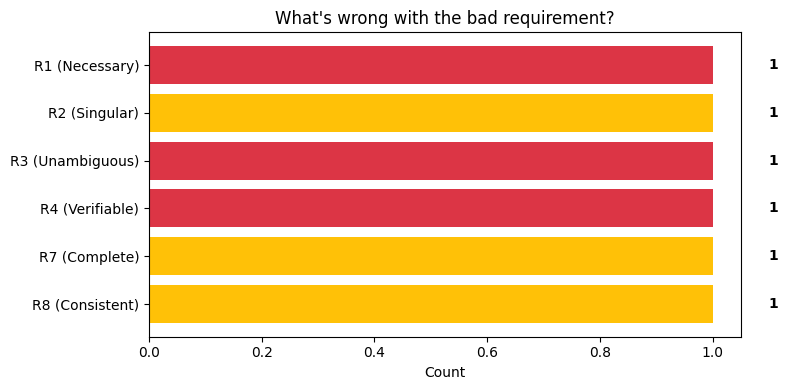

In [6]:
# Visualize the violations
plot_violations_by_rule(violations_bad, title="What's wrong with the bad requirement?")

**Key takeaway:** Good requirements are *singular* (one thing), *unambiguous* (no "should" or "maybe"),
*verifiable* (clear pass/fail criteria), and *necessary* (justified by a rationale).

## 5. Building a Specification

A **Spec** groups requirements together with hazards, contracts, and evidence.
Let's create a spec for a simple image classifier:

In [7]:
from vnvspec import Spec, Requirement

# Define 4 requirements
requirements = [
    Requirement(
        id="REQ-PROB",
        statement="The classifier shall produce probabilities in [0.0, 1.0].",
        rationale="Valid probability outputs for calibration.",
        verification_method="test",
        acceptance_criteria=["All outputs in [0.0, 1.0]."],
        priority="high",
    ),
    Requirement(
        id="REQ-DIM",
        statement="The classifier shall output exactly 3 class scores.",
        rationale="The dataset has 3 classes.",
        verification_method="test",
        acceptance_criteria=["Output dimension equals 3."],
    ),
    Requirement(
        id="REQ-NAN",
        statement="The classifier shall not produce NaN values.",
        rationale="NaN propagation causes silent failures.",
        verification_method="test",
        acceptance_criteria=["No NaN in any output tensor."],
        priority="high",
    ),
    Requirement(
        id="REQ-LATENCY",
        statement="The classifier shall produce a prediction within 50 ms per sample.",
        rationale="Real-time inference budget.",
        verification_method="test",
        acceptance_criteria=["p99 latency < 50 ms."],
    ),
]

spec = Spec(name="image-classifier-v1", requirements=requirements)
print(f"Spec '{spec.name}' has {len(spec.requirements)} requirements")
display_requirements_table(spec.requirements)

Spec 'image-classifier-v1' has 4 requirements


ID,Statement,Method,Priority
REQ-PROB,"The classifier shall produce probabilities in [0.0, 1.0].",test,high
REQ-DIM,The classifier shall output exactly 3 class scores.,test,medium
REQ-NAN,The classifier shall not produce NaN values.,test,high
REQ-LATENCY,The classifier shall produce a prediction within 50 ms per sample.,test,medium


In [8]:
# Batch quality check
print("Quality check for all requirements:\n")
all_violations = []
for req in spec.requirements:
    v = req.check_quality()
    all_violations.extend(v)
    status = "PASS" if not v else f"{len(v)} issues"
    print(f"  {req.id}: {status}")

print(f"\nTotal violations: {len(all_violations)}")

Quality check for all requirements:

  REQ-PROB: 1 issues
  REQ-DIM: 1 issues
  REQ-NAN: PASS
  REQ-LATENCY: PASS

Total violations: 2


## 6. A Simple "Model"

You don't need PyTorch to understand V&V! Let's use a plain Python function as our "model":

In [9]:
import random
import math

def simple_classifier(features: list[float]) -> list[float]:
    """A fake classifier that returns 3 class probabilities."""
    # Simulate some logits
    logits = [sum(f * w for f, w in zip(features, [0.3, -0.1, 0.5])) + random.gauss(0, 0.1)
              for _ in range(3)]
    # Softmax
    max_l = max(logits)
    exps = [math.exp(l - max_l) for l in logits]
    total = sum(exps)
    return [e / total for e in exps]

# Test it
sample_input = [0.5, 1.2, -0.3]
output = simple_classifier(sample_input)
print(f"Input:  {sample_input}")
print(f"Output: {[f'{p:.4f}' for p in output]}")
print(f"Sum:    {sum(output):.6f}")

Input:  [0.5, 1.2, -0.3]
Output: ['0.3255', '0.3371', '0.3374']
Sum:    1.000000


## 7. Creating Evidence

Now let's *verify* our model against the spec by running it on test data
and recording **Evidence** objects:

In [10]:
from vnvspec import Evidence
from datetime import datetime, UTC
import math

# Generate test data
test_data = [[random.gauss(0, 1) for _ in range(3)] for _ in range(100)]

# Run the model
outputs = [simple_classifier(x) for x in test_data]

# --- REQ-PROB: probabilities in [0, 1]? ---
all_in_range = all(0.0 <= p <= 1.0 for out in outputs for p in out)
ev_prob = Evidence(
    id="EV-PROB-001",
    requirement_id="REQ-PROB",
    kind="test",
    verdict="pass" if all_in_range else "fail",
    details={"samples": len(test_data), "all_in_range": all_in_range},
)

# --- REQ-DIM: output dimension == 3? ---
all_dim3 = all(len(out) == 3 for out in outputs)
ev_dim = Evidence(
    id="EV-DIM-001",
    requirement_id="REQ-DIM",
    kind="test",
    verdict="pass" if all_dim3 else "fail",
    details={"samples": len(test_data)},
)

# --- REQ-NAN: no NaN? ---
has_nan = any(math.isnan(p) for out in outputs for p in out)
ev_nan = Evidence(
    id="EV-NAN-001",
    requirement_id="REQ-NAN",
    kind="test",
    verdict="fail" if has_nan else "pass",
    details={"nan_count": sum(1 for out in outputs for p in out if math.isnan(p))},
)

# --- REQ-LATENCY: not tested yet ---
ev_latency = Evidence(
    id="EV-LAT-001",
    requirement_id="REQ-LATENCY",
    kind="test",
    verdict="inconclusive",
    details={"note": "Latency benchmark not yet run."},
)

evidence = [ev_prob, ev_dim, ev_nan, ev_latency]
display_evidence_table(evidence)

Evidence ID,Requirement,Kind,Verdict,Observed
EV-PROB-001,REQ-PROB,test,pass,2026-04-17 17:45
EV-DIM-001,REQ-DIM,test,pass,2026-04-17 17:45
EV-NAN-001,REQ-NAN,test,pass,2026-04-17 17:45
EV-LAT-001,REQ-LATENCY,test,inconclusive,2026-04-17 17:45


## 8. Building a Report

In [11]:
from vnvspec.core.assessment import Report

report = Report(
    spec_name=spec.name,
    spec_version=spec.version,
    evidence=evidence,
    summary={"test_samples": 100, "model": "simple_classifier"},
)

display_report_summary(report)

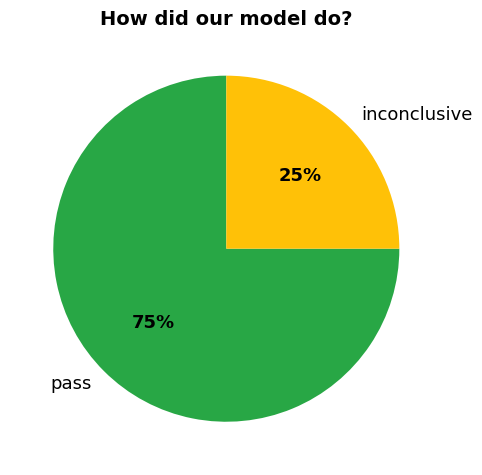

In [12]:
# Visualize verdicts
plot_evidence_verdicts(report.evidence, title="How did our model do?")

## 9. Coverage — Are All Requirements Tested?

Coverage summary: {'total': 4, 'covered': 4, 'uncovered': 0}


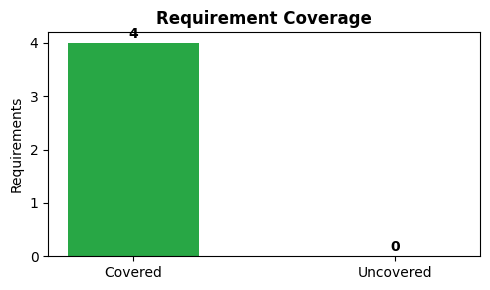

In [13]:
# Add evidence to the spec to check coverage
spec_with_ev = Spec(
    name=spec.name,
    requirements=spec.requirements,
    evidence=evidence,
)

print("Coverage summary:", spec_with_ev.coverage_summary())
plot_coverage(spec_with_ev)

## 10. Exporting Your Report

vnvspec can export reports in multiple formats:

In [14]:
from vnvspec.exporters import export_markdown, export_gsn_mermaid

# Markdown report
md_report = export_markdown(report)
print(md_report)

# V&V Report: image-classifier-v1 v0.1.0

Created: 2026-04-17T17:45:08.504177+00:00

## Summary

- **Overall verdict**: inconclusive
- **Pass**: 3
- **Fail**: 0
- **Total evidence**: 4

## Evidence

| ID | Requirement | Kind | Verdict | Artifact | Observed |
|---|---|---|---|---|---|
| EV-DIM-001 | REQ-DIM | test | **pass** |  | 2026-04-17T17:45:08.500417+00:00 |
| EV-LAT-001 | REQ-LATENCY | test | **inconclusive** |  | 2026-04-17T17:45:08.500502+00:00 |
| EV-NAN-001 | REQ-NAN | test | **pass** |  | 2026-04-17T17:45:08.500485+00:00 |
| EV-PROB-001 | REQ-PROB | test | **pass** |  | 2026-04-17T17:45:08.500370+00:00 |



In [15]:
# GSN assurance case (Mermaid diagram)
gsn = export_gsn_mermaid(report)
print(gsn)

flowchart TD
    G1["image-classifier-v1 v0.1.0: inconclusive"]
    S1["REQ-DIM"]
    G1 --> S1
    E_EV_DIM_001["EV-DIM-001: pass"]
    S1 --> E_EV_DIM_001
    S2["REQ-LATENCY"]
    G1 --> S2
    E_EV_LAT_001["EV-LAT-001: inconclusive"]
    S2 --> E_EV_LAT_001
    S3["REQ-NAN"]
    G1 --> S3
    E_EV_NAN_001["EV-NAN-001: pass"]
    S3 --> E_EV_NAN_001
    S4["REQ-PROB"]
    G1 --> S4
    E_EV_PROB_001["EV-PROB-001: pass"]
    S4 --> E_EV_PROB_001



In [16]:
from _helpers import display_mermaid
display_mermaid(gsn)

## 11. Traceability — Connecting the Dots

Real V&V requires *tracing* requirements to hazards, evidence, and standards.

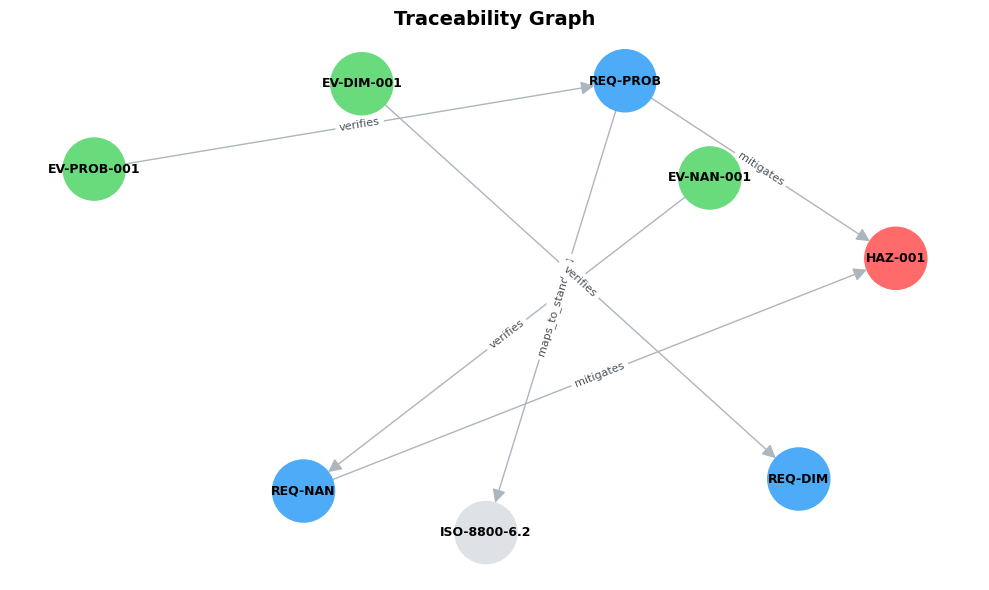

In [17]:
from vnvspec import TraceLink, Hazard, build_trace_graph
from vnvspec.core.trace import coverage_report
from _helpers import plot_trace_graph

# Define a hazard
haz = Hazard(
    id="HAZ-001",
    description="Incorrect classification leads to wrong action.",
    severity="S3", exposure="E4", controllability="C3", asil="D",
    mitigations=["REQ-PROB", "REQ-NAN"],
)

# Create trace links
links = [
    TraceLink(source_id="REQ-PROB", target_id="HAZ-001", relation="mitigates"),
    TraceLink(source_id="REQ-NAN", target_id="HAZ-001", relation="mitigates"),
    TraceLink(source_id="EV-PROB-001", target_id="REQ-PROB", relation="verifies"),
    TraceLink(source_id="EV-NAN-001", target_id="REQ-NAN", relation="verifies"),
    TraceLink(source_id="EV-DIM-001", target_id="REQ-DIM", relation="verifies"),
    TraceLink(source_id="REQ-PROB", target_id="ISO-8800-6.2", relation="maps_to_standard"),
]

plot_trace_graph(links)

## 12. Standards Registries

vnvspec ships with clause databases for major safety standards:

In [18]:
from vnvspec.registries import list_available
print("Available registries:", list_available())

Available registries: ['eu_ai_act', 'iso_21448', 'iso_pas_8800', 'nist_ai_rmf', 'ul_4600']


In [19]:
display_registry_sample("iso_pas_8800", n=8)

Clause,Title,Level,Summary
5,AI safety lifecycle overview,informative,Defines the overall lifecycle for managing safety of AI-based systems in road ve...
5.1,General principles for AI safety,shall,Establishes foundational principles for ensuring AI components in vehicles meet ...
5.2,AI safety plan,shall,Requires creation and maintenance of a safety plan that addresses AI-specific ri...
5.3,Integration with ISO 26262,shall,Describes how AI safety activities integrate with the functional safety lifecycl...
5.4,Integration with ISO 21448 (SOTIF),should,Explains the relationship between AI safety management and SOTIF processes for h...
6,AI safety requirements,informative,Covers derivation and specification of safety requirements that are specific to ...
6.1,Hazard analysis for AI components,shall,Requires systematic identification of hazards that may arise from AI-specific fa...
6.2,AI safety requirements specification,shall,"Defines how to derive safety requirements for AI elements from hazard analysis, ..."


## Summary

| Concept | What it is | vnvspec class |
|---------|-----------|---------------|
| Requirement | A testable "shall" statement | `Requirement` |
| Specification | Collection of requirements + context | `Spec` |
| Evidence | Proof that a requirement is met | `Evidence` |
| Hazard | An identified risk | `Hazard` |
| Traceability | Links between all artifacts | `TraceLink` |
| Report | Assessment results | `Report` |
| Catalog | Pre-written best-practice requirements | `vnvspec.catalog.*` |

**Next steps:**
- Try Notebook 2 (SE perspective) for standards compliance and formal traceability
- Try Notebook 3 (ML perspective) for PyTorch model wrapping and automated assessment
- Run `vnvspec catalog list` to see all available catalogs

## 13. Using Catalogs (v0.3)

vnvspec ships with **curated best-practice catalogs** — pre-written requirements
for common packages. Instead of writing 30+ requirements by hand, you import them:

In [20]:
from vnvspec.catalog.ml.pytorch_training import reproducibility, gradient_health

# Import catalog requirements
repro_reqs = reproducibility()
grad_reqs = gradient_health()
print(f"Reproducibility: {len(repro_reqs)} requirements")
print(f"Gradient health: {len(grad_reqs)} requirements")

# Show the first requirement
req = repro_reqs[0]
print(f"\n{req.id}: {req.statement[:80]}...")
print(f"  Priority: {req.priority}")
print(f"  Sources: {req.source}")
print(f"  Standards: {req.standards}")

Reproducibility: 6 requirements
Gradient health: 7 requirements

CAT-PYT-REPRO-001: The training script shall set torch.manual_seed, numpy.random.seed, random.seed,...
  Priority: blocking
  Sources: ['https://docs.pytorch.org/docs/stable/notes/randomness.html']
  Standards: {'nist_ai_rmf': ['MS-2.7'], 'ieee_754': ['11'], 'nasa_se_handbook': ['5.3'], 'do_178c': ['6.3']}


In [21]:
# Compose catalogs into your spec using extend()
from vnvspec import Spec

my_spec = Spec(name="my-training-run", requirements=[
    Requirement(
        id="REQ-CUSTOM-001",
        statement="The model shall achieve test accuracy above 0.90.",
        rationale="Deployment threshold.",
        verification_method="test",
        acceptance_criteria=["Test accuracy > 0.90."],
        priority="blocking",
    ),
]).extend(repro_reqs, grad_reqs)

print(f"Combined spec: {len(my_spec.requirements)} requirements")
print(f"  1 custom + {len(repro_reqs)} reproducibility + {len(grad_reqs)} gradient health")

Combined spec: 14 requirements
  1 custom + 6 reproducibility + 7 gradient health


## 14. The Verdict Fix (v0.3)

In v0.3, `Report.verdict()` correctly returns `"inconclusive"` when inconclusive evidence is present.
Previously it silently upgraded to `"pass"` — a V&V trust bug:

In [22]:
from vnvspec import Report, Evidence

# A report with mixed pass + inconclusive evidence
mixed_report = Report(
    spec_name="demo",
    evidence=[
        Evidence(id="E1", requirement_id="R1", kind="test", verdict="pass"),
        Evidence(id="E2", requirement_id="R2", kind="test", verdict="inconclusive"),
    ],
)

print(f"Strict (default):  {mixed_report.verdict()}")  # → inconclusive

# Opt-in to old behavior
lenient_report = Report(
    spec_name="demo",
    evidence=mixed_report.evidence,
    verdict_policy="lenient",
)
print(f"Lenient (opt-in):  {lenient_report.verdict()}")  # → pass

Strict (default):  inconclusive
Lenient (opt-in):  pass
